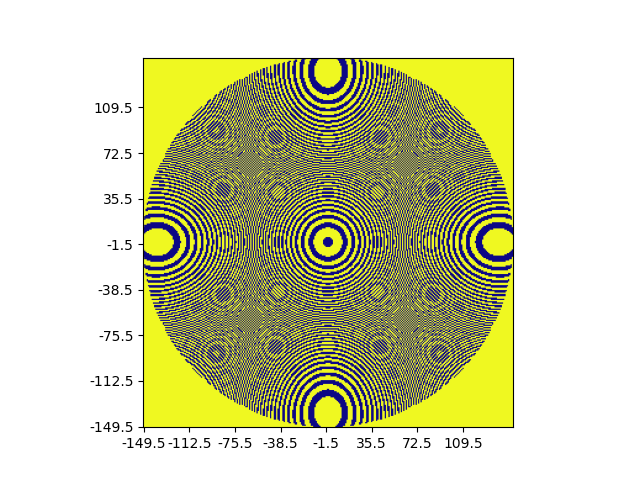

In [1]:
config_path = "RS_results/collimator_220μm_300/config.yaml"
import numpy as np; import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
import src.RS as RS
import src.math_tool as mt
import src.img_tool as it
import src.load_config as lc
import src.utils as utils
from tqdm import tqdm
import gc
%matplotlib widget
%load_ext autoreload
%autoreload 2
c, π = lc.load_RS(config_path), np.pi
if (np.array([c.A.Nx, c.A.Ny]) != np.array(c.aperture.shape)).any():
    raise Exception(f'error: loaded aperture dimension mismatch\nloaded file size: {c.aperture.shape}')
plt.imshow(c.aperture.T, cmap='plasma')
plt.gca().invert_yaxis()
plt.xticks(c.A.x_tick_idxs, c.A.xs[c.A.x_tick_idxs])
plt.yticks(c.A.y_tick_idxs, c.A.ys[c.A.y_tick_idxs])
plt.show()

In [2]:
# let source be 1μm^2 area with E=1
# since unit is μm, Δx=Δy=1 (μm)

Axs2D, Ays2D = np.meshgrid(c.A.xs, c.A.ys, indexing='ij')
# since input light is point source 220μm behind collimator
Az = 220
r0 = mt.dist(Axs2D, Ays2D, z=Az, x_c=0,y_c=0,z_c=0) # A.Nx, A.Ny
E0 = -1j/c.λ * Az * (np.exp(c.k*1j*r0)/r0**2) # A.Nx, A.Ny
# initial  E field shielded by aperture
Axy = E0 * c.aperture

In [3]:
print(Axy.shape)

(300, 300)


In [3]:
batch_size = 512
batch_idx = utils.batch_idx(Axy.size, batch_size)
print(f'ram needed = {batch_size *(c.sim.Nx*c.sim.Ny)*128/8/1024**3 * c.sim.num_process}GB * {len(batch_idx)} Iteration')

ram needed = 0.6866455078125GB * 176 Iteration


In [6]:
z=2e6
A_cfg = (Axy, c.A.xs, c.A.ys)
sim_cfg = (c.sim.xs, c.sim.ys, z, c.λ)
method_cfg = (batch_size, c.path.E2, c.sim.num_process)
RS.RS_batch_Multi_Process(A_cfg, sim_cfg, method_cfg)

process 0 started


Rayleigh Sommerfeld: 100%|██████████| 176/176 [07:59<00:00,  2.72s/it]


(300, 300)


In [9]:
path = "./E/collimator_220μm_300"
E_1m = np.load(f"{path}/Z=1000000.0.npy")
E_2m = np.load(f"{path}/Z=2000000.0.npy")

In [10]:
print((np.abs(E_1m)**2).sum())
print((np.abs(E_2m)**2).sum())

0.008203239112486516
0.0020708450540555283
